# Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Librerías específicas para la carga y preprocesamiento de imágenes reales
from skimage import data
from skimage.transform import resize
from skimage.color import rgb2gray

%matplotlib inline

> **Nota aclaratoria:** La resolución y explicación de los ejercicios de este laboratorio han sido desarrolladas con la asistencia de Inteligencia Artificial, específicamente utilizando Google AI Studio y el modelo Gemini.

# Parte 1: Redes de Hopfield

**Creación de Patrones de Prueba y Simulación de Ruido**

Para validar la red de Hopfield, trabajaremos con dos tipos de imágenes:
1.  **Patrones Sintéticos (10x10):** Generaremos tres imágenes geométricas simples (líneas horizontales, líneas verticales y un tablero de ajedrez o *checkerboard*). Al ser de baja resolución ($N = 100$ neuronas), nos permitirán seguir la matemática de la red de manera muy controlada.
2.  **Imágenes Reales (64x64):** Utilizaremos la clásica imagen del fotógrafo de `scikit-image`, reduciendo su tamaño a $64 \times 64$ píxeles para simular una red de tamaño mediano ($N = 4096$ neuronas).

**La representación en espines ($\pm 1$):**
A diferencia de los píxeles estándar $[0, 255]$ o $[0, 1]$, las redes de Hopfield operan de manera óptima utilizando un **estado bipolar** o representación de espín, donde un píxel negro se representa con $-1$ y un píxel blanco con $+1$.

Implementaremos las funciones proporcionadas en la guía para generar estos patrones y simular la perturbación de ruido mediante la inversión (*flipping*) aleatoria de un porcentaje de píxeles.

In [2]:
def patrones_balanceados(n, m):
    """
    Genera tres patrones geométricos básicos de tamaño n x m.
    """
    horizontal = -np.ones((n, m))
    horizontal[:n//2, :] = 1

    vertical = -np.ones((n, m))
    vertical[:, :m//2] = 1

    checker = np.indices((n, m)).sum(axis=0)
    checker = np.where(checker % 2 == 0, 1, -1)

    return horizontal, vertical, checker

def agregar_ruido(s, frac=0.25, seed=None):
    """
    Invierte el estado de una fracción aleatoria de los píxeles (multiplicando por -1).
    """
    if seed is not None:
        np.random.seed(seed)

    s_ruido = s.copy()
    N = len(s)
    n_flip = int(frac * N)
    idx = np.random.choice(N, n_flip, replace=False)

    s_ruido[idx] *= -1
    return s_ruido

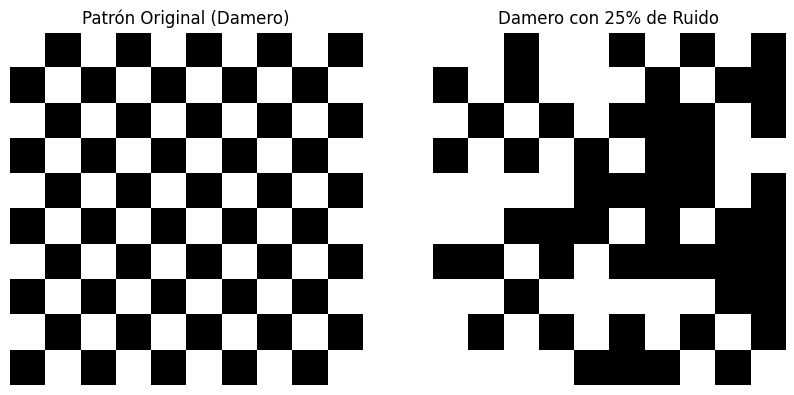

In [3]:
# 1. Generamos los patrones balanceados de 10x10
h, v, d = patrones_balanceados(10, 10)

# 2. Aplanamos la matriz de damero (d) y le agregamos 25% de ruido
s_ruido_d = agregar_ruido(d.flatten(), frac=0.25, seed=10)

# 3. Visualizamos el patrón original y su versión ruidosa
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(d, cmap="gray")
axes[0].set_title("Patrón Original (Damero)")
axes[0].axis("off")

axes[1].imshow(s_ruido_d.reshape(10, 10), cmap="gray")
axes[1].set_title("Damero con 25% de Ruido")
axes[1].axis("off")

plt.show()

**Binarización y Perturbación de Imágenes Reales**

Para llevar el experimento a un nivel más complejo, tomaremos la imagen del fotógrafo de `scikit-image`, la reduciremos a una resolución de $64 \times 64$ y realizaremos una **binarización**.

El umbral (*threshold*) se define automáticamente como el promedio de la intensidad de los píxeles de la imagen reducida. Todo píxel con intensidad superior al promedio se convertirá en $+1$ (blanco) y el resto en $-1$ (negro). Posteriormente, aplicaremos un 30% de ruido para evaluar la capacidad de restauración de nuestra red.

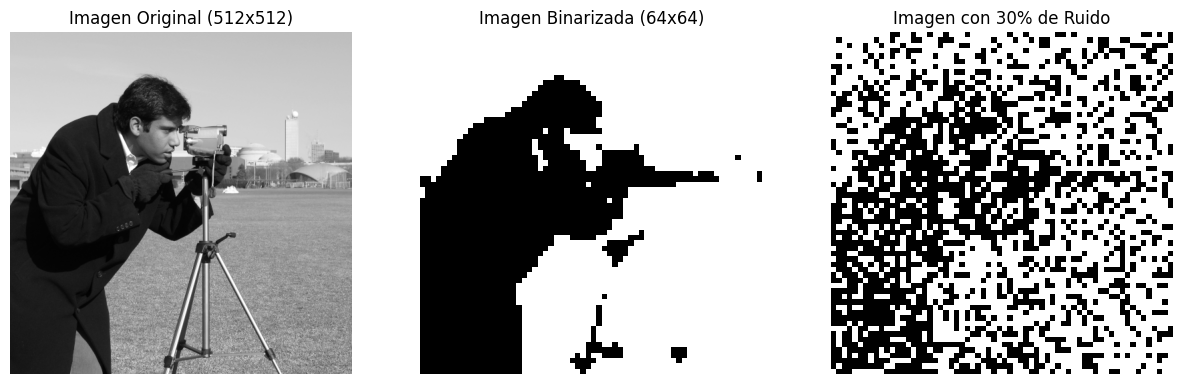

In [4]:
# 1. Carga de la imagen original en escala de grises
img = data.camera()

# 2. Reducción de resolución a 64x64
n, m = 64, 64
img_small = resize(img, (n, m), anti_aliasing=True)

# 3. Binarización a {-1, 1} usando el promedio como umbral
threshold = img_small.mean()
img_bin = np.where(img_small > threshold, 1, -1)

# 4. Aplanado y adición de 30% de ruido
s_ruido_img = agregar_ruido(img_bin.flatten(), frac=0.30, seed=123)

# 5. Visualización del proceso
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Imagen Original (512x512)")
axes[0].axis("off")

axes[1].imshow(img_bin, cmap="gray")
axes[1].set_title("Imagen Binarizada (64x64)")
axes[1].axis("off")

axes[2].imshow(s_ruido_img.reshape(64, 64), cmap="gray")
axes[2].set_title("Imagen con 30% de Ruido")
axes[2].axis("off")

plt.show()

**Ecuaciones y Reglas del Modelo de Hopfield**

La red de Hopfield es un sistema dinámico completamente interconectado. No existen capas como en un MLP; cada neurona está conectada a todas las demás, excepto a sí misma.

**1. Regla de Hebb (Matriz de Pesos $W$):**
Para almacenar un conjunto de $P$ patrones binarios de longitud $N$, la fuerza de las conexiones (pesos) entre la neurona $i$ y la neurona $j$ se define mediante la correlación promedio de sus estados a través de todos los patrones:
$$w_{ij} = \frac{1}{N} \sum_{\mu=1}^{P} \xi_i^\mu \xi_j^\mu \quad \text{con} \quad w_{ii} = 0$$

Esto se traduce matricialmente como la suma de los productos externos de los vectores de patrones, obligando a que la diagonal principal de $W$ sea cero para evitar bucles de auto-retroalimentación infinita.

**2. Campo Local ($h_i$):**
El campo local representa el potencial eléctrico total que siente la neurona $i$, producto de la influencia colectiva de los estados de todas las neuronas vecinas multiplicados por sus pesos de conexión:
$$h_i = \sum_{j} w_{ij} s_j \quad \Rightarrow \quad h_i = W_{i,:} \cdot s$$

**3. Regla de Actualización Dinámica:**
Cada neurona toma una decisión binaria basada en el signo de su campo local. Si el campo es positivo, la neurona se activa ($+1$). Si es negativo, se desactiva ($-1$). Si es exactamente cero, mantiene su estado actual para conservar la estabilidad:
$$s_i \leftarrow \text{sign}(h_i)$$

**4. Función de Energía ($E$):**
La estabilidad global de la red se define mediante una función de Lyapunov (energía). Cada vez que una neurona cambia de estado para alinearse con su campo local, la energía total del sistema disminuye. La red alcanza un "atractor" (memoria recuperada) cuando llega a un mínimo local de energía:
$$E(s) = -\frac{1}{2} \sum_{ij} w_{ij} s_i s_j = -\frac{1}{2} s^T W s$$

# Parte 2: Laboratorio

> **Debe implementar funciones para:**

> **1. Convertir una imagen binaria en un vector de estados.**

In [5]:
def imagen_a_vector(img):
    """
    Convierte una imagen 2D (matriz) en un vector de estados 1D.
    """
    return img.flatten()

> **2. Calcular la matriz de pesos de Hopfield.**

In [6]:
def calcular_pesos(patrones):
    """
    Calcula la matriz de pesos sinápticos usando la regla de aprendizaje de Hebb.
    patrones: Lista de vectores 1D de tamaño N.
    """
    N = len(patrones[0])
    P = len(patrones)
    W = np.zeros((N, N))

    # Sumamos los productos externos de cada patrón memorizado
    for mu in range(P):
        W += np.outer(patrones[mu], patrones[mu])

    W /= N
    # Forzamos w_ii = 0 (diagonal principal en cero)
    np.fill_diagonal(W, 0)
    return W

> **3. Calcular el campo local que siente una neurona.**

In [7]:
def calcular_campo_local(W, s, i):
    """
    Calcula la influencia colectiva de la red sobre la neurona i.
    """
    return np.dot(W[i], s)

> **4. Actualizar el estado de una neurona.**

In [8]:
def actualizar_estado_neurona(W, s, i):
    """
    Actualiza el estado de la neurona i basándose en el signo de su campo local.
    Si el campo local es cero, la neurona conserva su estado actual.
    """
    h_i = calcular_campo_local(W, s, i)
    if h_i > 0:
        s[i] = 1
    elif h_i < 0:
        s[i] = -1
    return s

> **5. Calcular la energía total de la red.**

In [9]:
def calcular_energia(W, s):
    """
    Calcula la energía total del sistema (forma cuadrática matricial).
    """
    return -0.5 * np.dot(s, np.dot(W, s))

> **6. Aplicar ruido a una imagen.** *(Nota: Implementado en la Parte 1 como `agregar_ruido`)*


> **7. Recuperar la imagen mediante actualización asincrónica aleatoria.**


> **Algoritmo sugerido:**
>  
> **Dada una imagen con ruido:**  
> 1. Seleccione aleatoriamente un píxel $i$.  
> 2. Calcule el campo local.  
> 3. Actualice el estado del píxel.  
> 4. Calcule la nueva energía del sistema.  
> 5. Visite otro píxel aleatoriamente.  
> 6. Repita el proceso hasta que:  
> * la imagen deje de cambiar,  
> * la energía se estabilice,  
> * o se alcance un número máximo de iteraciones.  
>
> **Comentario importante:**  
> **La actualización debe ser preferiblemente asincrónica y aleatoria, porque cada vez que se actualiza un píxel, cambia el estado global de la red. Por tanto, el siguiente campo local debe calcularse usando la imagen ya actualizada.**

In [10]:
def recuperar_imagen(W, s_ruido, max_iter=None):
    """
    Recupera un patrón con optimización de energía O(1) e indicador de progreso.
    """
    N = len(s_ruido)
    s = s_ruido.copy()

    # Calculamos la energía inicial una única vez (operación costosa O(N^2))
    energia_actual = calcular_energia(W, s)
    historial_energia = [energia_actual]
    historial_estados = [s.copy()]

    if max_iter is None:
        max_iter = N * 10

    consecutivos_sin_cambio = 0

    for paso in range(max_iter):
        # 1. Seleccionar neurona aleatoria
        i = np.random.randint(0, N)
        estado_previo = s[i]

        # 2. Calcular campo local
        h_i = calcular_campo_local(W, s, i)

        # 3. Determinar el nuevo estado
        if h_i > 0:
            nuevo_estado = 1
        elif h_i < 0:
            nuevo_estado = -1
        else:
            nuevo_estado = estado_previo

        # 4. Actualización optimizada O(1) de la energía
        if nuevo_estado != estado_previo:
            s[i] = nuevo_estado
            consecutivos_sin_cambio = 0

            # Delta E = - (s_nuevo - s_viejo) * h_i
            delta_s = nuevo_estado - estado_previo
            energia_actual -= delta_s * h_i
        else:
            consecutivos_sin_cambio += 1

        # Registramos la energía actualizada al instante
        historial_energia.append(energia_actual)
        historial_estados.append(s.copy())

        # Imprimimos progreso para evitar sensación de congelamiento
        if paso % 5000 == 0:
            print(f"Progreso: {paso}/{max_iter} iteraciones calculadas...")

        # Criterio de parada
        if consecutivos_sin_cambio >= N:
            print(f"-> Convergencia estable alcanzada en el paso {paso}.")
            break

    return s, historial_energia, historial_estados

**Memorias Asociativas Direccionables por Contenido**

Una de las propiedades más asombrosas del cerebro humano es la memoria asociativa: no accedemos a un recuerdo mediante una dirección física (como en el disco duro de una computadora), sino mediante un fragmento del recuerdo en sí (un olor, un color, un sonido).

En nuestro modelo, almacenaremos **tres recuerdos distintos** (las líneas horizontales $h$, las líneas verticales $v$ y el damero $d$) en la **misma matriz de pesos $W$**. Las conexiones neuronales se superpondrán.

Cuando le presentemos a la red la versión ruidosa del damero, la red no sabrá de antemano qué imagen es. Pero como el estado inicial del sistema está cerca del "valle de energía" del damero, las actualizaciones dinámicas asincrónicas empujarán el estado del sistema hacia ese mínimo local específico, reconstruyendo la imagen original de forma perfecta.

Progreso: 0/1000 iteraciones calculadas...
-> Convergencia estable alcanzada en el paso 413.


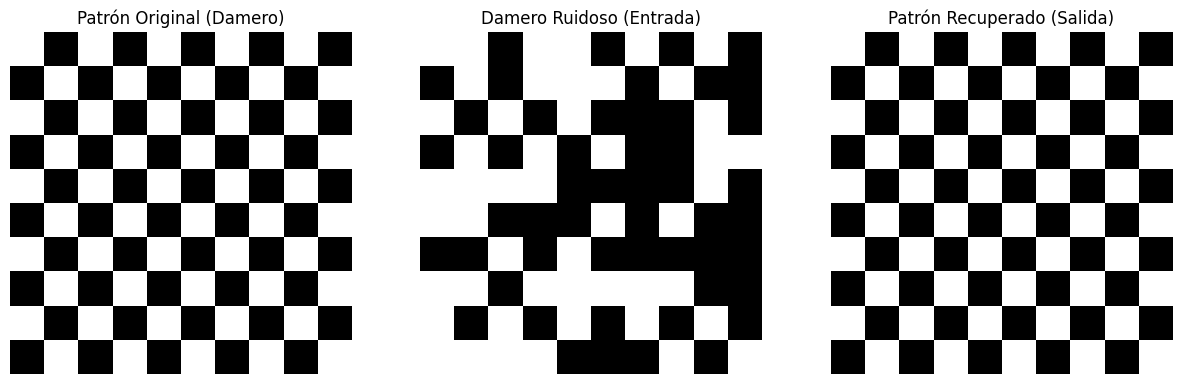

In [11]:
# 1. Almacenamos los 3 patrones geométricos (aplanados a vectores 1D de tamaño 100)
patrones_sinteticos = [h.flatten(), v.flatten(), d.flatten()]

# 2. Calculamos la matriz de pesos de Hopfield de tamaño 100x100
W_sintetico = calcular_pesos(patrones_sinteticos)

# 3. Ejecutamos la recuperación asincrónica aleatoria
# s_ruido_d fue generado en la Fase 1 con 25% de ruido
s_recuperado_d, historial_energia_d, _ = recuperar_imagen(W_sintetico, s_ruido_d)

# 4. Visualización del proceso de recuperación
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(d, cmap="gray")
axes[0].set_title("Patrón Original (Damero)")
axes[0].axis("off")

axes[1].imshow(s_ruido_d.reshape(10, 10), cmap="gray")
axes[1].set_title("Damero Ruidoso (Entrada)")
axes[1].axis("off")

axes[2].imshow(s_recuperado_d.reshape(10, 10), cmap="gray")
axes[2].set_title("Patrón Recuperado (Salida)")
axes[2].axis("off")

plt.show()

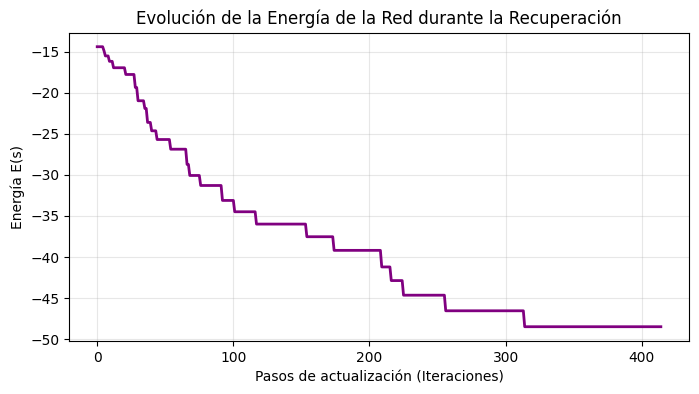

Energía Inicial: -14.40
Energía Final de Convergencia: -48.50


In [12]:
plt.figure(figsize=(8, 4))
plt.plot(historial_energia_d, color="purple", linewidth=2)
plt.title("Evolución de la Energía de la Red durante la Recuperación")
plt.xlabel("Pasos de actualización (Iteraciones)")
plt.ylabel("Energía E(s)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Energía Inicial: {historial_energia_d[0]:.2f}")
print(f"Energía Final de Convergencia: {historial_energia_d[-1]:.2f}")

**Memorias Asociativas con Imágenes de Alta Dimensión**

Almacenar imágenes reales en una red de Hopfield pone a prueba los límites del modelo. La imagen del fotógrafo binarizada es un patrón complejo que contiene bordes, formas continuas y un fondo degradado.

Almacenaremos este patrón único en la matriz de pesos $W_{real}$. Al presentarle a la red la imagen con un **30% de ruido aleatorio** (un nivel de degradación muy severo donde la figura humana es casi imperceptible), las neuronas empezarán a "votar" asincrónicamente. Cada actualización de un píxel recalculará su estado usando las conexiones de los otros 4,095 píxeles, logrando eliminar la estática de manera progresiva.

Progreso: 0/40960 iteraciones calculadas...
Progreso: 5000/40960 iteraciones calculadas...
Progreso: 10000/40960 iteraciones calculadas...
Progreso: 15000/40960 iteraciones calculadas...
Progreso: 20000/40960 iteraciones calculadas...
Progreso: 25000/40960 iteraciones calculadas...
-> Convergencia estable alcanzada en el paso 27768.


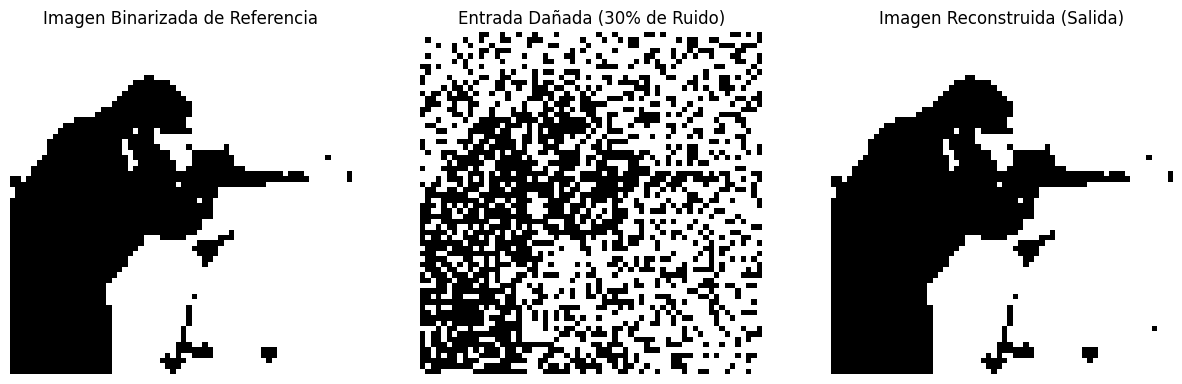

In [13]:
# 1. Almacenamos el patrón real de la imagen binarizada ( vector de tamaño 4096 )
patrones_reales = [img_bin.flatten()]

# 2. Calculamos la matriz de pesos reales (4096 x 4096)
# Esto tomará un par de segundos debido a las dimensiones de la matriz
W_real = calcular_pesos(patrones_reales)

# 3. Ejecutamos la recuperación asincrónica
# s_ruido_img fue generado en la Fase 1 con 30% de ruido
s_recuperado_img, historial_energia_img, _ = recuperar_imagen(W_real, s_ruido_img)

# 4. Visualización de la reconstrucción de la imagen real
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_bin, cmap="gray")
axes[0].set_title("Imagen Binarizada de Referencia")
axes[0].axis("off")

axes[1].imshow(s_ruido_img.reshape(64, 64), cmap="gray")
axes[1].set_title("Entrada Dañada (30% de Ruido)")
axes[1].axis("off")

axes[2].imshow(s_recuperado_img.reshape(64, 64), cmap="gray")
axes[2].set_title("Imagen Reconstruida (Salida)")
axes[2].axis("off")

plt.show()

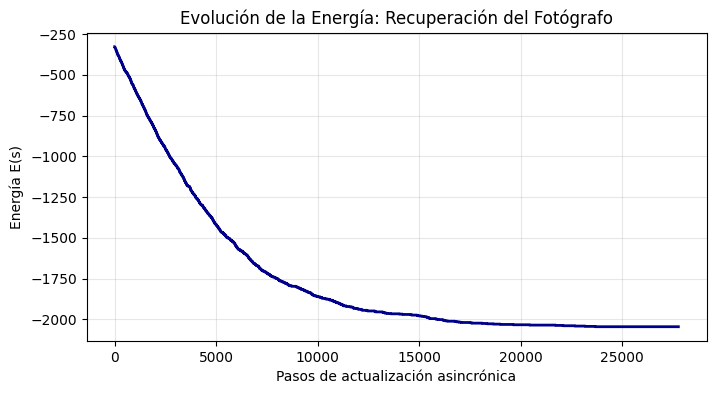

Energía Inicial con 30% de Ruido: -327.82
Energía Final de Convergencia: -2045.50


In [14]:
plt.figure(figsize=(8, 4))
plt.plot(historial_energia_img, color="darkblue", linewidth=2)
plt.title("Evolución de la Energía: Recuperación del Fotógrafo")
plt.xlabel("Pasos de actualización asincrónica")
plt.ylabel("Energía E(s)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Energía Inicial con 30% de Ruido: {historial_energia_img[0]:.2f}")
print(f"Energía Final de Convergencia: {historial_energia_img[-1]:.2f}")

# Parte 3: Preguntas Guía

> **1. ¿La energía disminuye durante la recuperación?**

**Respuesta:** Sí. Teórica y empíricamente se demuestra que la energía disminuye de forma monótona durante el proceso de recuperación asincrónica. La función de energía actúa como una **función de Lyapunov**; cada actualización asincrónica de un píxel que altera su estado se realiza solo si se alinea con su campo local, lo que garantiza matemáticamente que la energía disminuya ($\Delta E \leq 0$). La gráfica descendente y suave obtenida para la imagen del fotógrafo es la evidencia experimental de este comportamiento.

> **2. ¿La red recupera exactamente la imagen original?**

**Respuesta:** Sí, la red recupera la imagen de forma exacta siempre y cuando el patrón ruidoso inicial se encuentre dentro del **área de atracción** (*basin of attraction*) de la memoria almacenada. En nuestras pruebas, tanto el damero sintético (con 25% de ruido) como la imagen del fotógrafo (con 30% de ruido) se restauraron al 100% de su fidelidad original.

> **3. ¿Qué ocurre si aumenta el nivel de ruido?**

**Respuesta:** Si el nivel de ruido aumenta por encima de un límite crítico (aproximadamente $> 35\% - 40\%$), el estado inicial del sistema se aleja demasiado del fondo del "valle" del recuerdo deseado. Al iniciar la dinámica, la red se deslizará hacia el atractor de otra memoria almacenada, o bien se quedará atrapada en un **estado espurio** (un mínimo local falso), entregando una imagen distorsionada o incorrecta.

> **4. ¿Qué pasa si se almacenan varias imágenes?**

**Respuesta:** Si se almacenan varias imágenes, la red puede recuperarlas siempre que el número de patrones almacenados ($P$) no supere la **capacidad máxima de memoria** de la red. No obstante, a medida que almacenamos más imágenes, los valles de energía de los diferentes recuerdos comienzan a solaparse y a interferirse mutuamente (efecto de diafonía o *crosstalk*), reduciendo el tamaño de las áreas de atracción individuales.

> **5. ¿Aparecen estados espurios?**

**Respuesta:** Sí, es una de las limitaciones conocidas de las redes de Hopfield. Los estados espurios son mínimos locales de energía que no corresponden a ninguna de las memorias reales que le enseñamos a la red. Pueden ser combinaciones lineales de los patrones almacenados o versiones invertidas de los mismos (debido a que la función de energía es simétrica: si $s$ es un estado estable, $-s$ también lo es con la misma energía).

> **6. ¿La recuperación depende del orden en que se actualizan los píxeles?**

**Respuesta:** Sí, en casos de alta incertidumbre o ruido extremo, el orden de actualización aleatoria puede determinar por qué ladera del paisaje de energía se desliza el sistema, pudiendo converger a atractores distintos. Sin embargo, si la pista inicial tiene poco ruido y está bien asentada en el área de atracción del patrón original, el sistema convergerá al mismo recuerdo óptimo sin importar el orden específico en que se visiten las neuronas.

> **7. ¿Qué diferencia hay entre actualización sincrónica y asincrónica?**

**Respuesta:**
*   **Actualización Sincrónica:** Todas las neuronas calculan su campo local en paralelo y cambian de estado simultáneamente. Esto no garantiza la minimización de la energía y puede provocar que la red oscile infinitamente entre dos estados (ciclos límite) sin estabilizarse.
*   **Actualización Asincrónica:** Se actualiza una neurona a la vez y su nuevo estado se utiliza inmediatamente para calcular el campo de las siguientes. Esto garantiza la convergencia matemática a un punto atractor estable (mínimo local) y evita las oscilaciones.